# Internship Assignment: Customer Churn Data Preprocessing & Exploratory Data Analysis

**Author:** Data Science & ML Intern  
**Project Title:** Customer Churn Data Preprocessing & Exploratory Data Analysis  
**Domain:** Telecommunications / Customer Retention  
**Technology Stack:** Python 3, NumPy, Pandas, Matplotlib, Seaborn, Scikit-Learn  

---

## Executive Summary & Objectives

Data preprocessing and Exploratory Data Analysis (EDA) are foundational steps in the Machine Learning lifecycle. Raw real-world datasets are inherently messy, containing missing entries, outliers, duplicate records, non-standardized categorical formatting, and uninformative features.

This project delivers a complete end-to-end preprocessing workflow on a Customer Churn dataset, covering:
1. **Python & ML Fundamentals**: Environment setup, modular imports, and key data structures (`NumPy` arrays, `Pandas` DataFrames).
2. **Data Loading & Inspection**: Examining dataset shape, data types, missing value distribution, and memory usage.
3. **Data Cleaning & Standardisation**: Removing duplicate rows, parsing hidden blank spaces (`" "`), and unifying typo-laden categorical text.
4. **Missing Value Imputation**: Imputing missing numerical attributes using median strategy and missing categorical attributes using mode strategy.
5. **Outlier Detection & Treatment**: Applying Interquartile Range (IQR) bounds for IQR-based capping of extreme non-physical values.
6. **Feature Selection**: Identifying and dropping non-predictive keys (`CustomerID`) and redundant noise variables.
7. **Categorical Variable Encoding**: Applying Binary Encoding and One-Hot Encoding for downstream model compatibility.
8. **Numerical Feature Scaling**: Standardizing continuous variables (`StandardScaler`) to zero mean and unit variance.
9. **Exploratory Data Analysis (EDA)**: Visualizing target distributions, cross-feature churn relationships, and correlation matrices.
10. **Before-vs-After Comparison**: Quantitative verification of dataset quality before and after preprocessing.


## 1. Environment Setup & Library Imports

We begin by importing required numerical computing, data manipulation, visualization, and machine learning preprocessing packages.

In [1]:
import os
import sys

# Ensure root directory is in sys.path for importing local modules
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from src.utils import inspect_dataset_summary, compute_iqr_outliers, generate_before_after_comparison
from src.data_preprocessing import ChurnDataPreprocessor

# Display configurations
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 1000)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

print("All libraries imported successfully!")


All libraries imported successfully!


## 2. Data Loading & Initial Dataset Inspection

We load the raw customer churn dataset from `../data/raw/customer_churn_raw.csv` and inspect its structure.

In [2]:
raw_csv_path = "../data/raw/customer_churn_raw.csv"
raw_df = pd.read_csv(raw_csv_path)

print(f"Dataset Loaded Successfully! Shape: {raw_df.shape} (Rows, Columns)")
raw_df.head(10)


Dataset Loaded Successfully! Shape: (1210, 19) (Rows, Columns)


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,TenureMonths,PhoneService,MultipleLines,InternetService,OnlineSecurity,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,SystemLogCode,RandomNoiseScore,Churn
0,CUST-10101,Female,0.0,No,No,58.0,Yes,No,DSL,No,Yes,Month-to-month,No,Bank transfer,54.74,3224.65,SYS_B,63.736097,No
1,CUST-10432,Female,1.0,Yes,Yes,25.0,Yes,No,Fiber optic,Yes,No,Month-to-month,No,Electronic check,107.38,2618.02,SYS_A,61.903762,Yes
2,CUST-10309,Male,0.0,Yes,No,67.0,Yes,No,Fiber optic,Yes,Yes,One year,No,Electronic check,85.38,5699.19,SYS_B,21.236531,No
3,CUST-10109,NaN,0.0,No,No,44.0,Yes,No,No,No internet service,No internet service,Two year,Yes,Bank transfer,NaN,882.51,SYS_C,49.742428,No
4,CUST-10652,Female,0.0,No,No,1.0,Yes,No,Fiber optic,Yes,No,Month-to-month,No,Bank transfer,74.61,104.23,SYS_C,41.865214,No
5,CUST-10943,Female,0.0,No,Yes,6.0,Yes,No,DSL,No,Yes,One year,Yes,Credit card,62.00,402.61,SYS_A,48.595583,No
6,CUST-10231,Female,0.0,No,No,72.0,Yes,Yes,Fiber optic,No,No,Month-to-month,Yes,Credit card,93.89,6693.47,SYS_A,69.887311,No
7,CUST-10049,Male,0.0,Yes,No,44.0,Yes,No,Fiber optic,No,Yes,Two year,Yes,Mailed check,92.07,4087.15,SYS_C,51.372371,Yes
8,CUST-11040,F,0.0,Yes,Yes,55.0,Yes,No,DSL,Yes,Yes,Month-to-month,Yes,Credit card,56.91,3036.05,SYS_B,54.011496,No
9,CUST-11187,Male,1.0,No,No,49.0,Yes,No,Fiber optic,No,No,Two year,Yes,Mailed check,109.96,5389.22,SYS_A,81.429328,No


### 2.1 Dataset Structural & Diagnostic Assessment
Checking column data types, missing value counts, and duplicate records.

In [3]:
print("=== DATASET INFORMATION ===")
raw_df.info()

print("\n=== MISSING VALUES COUNT PER COLUMN ===")
missing_summary = raw_df.isna().sum()
missing_pct = (raw_df.isna().sum() / len(raw_df)) * 100
missing_table = pd.DataFrame({"Missing Count": missing_summary, "Percentage (%)": missing_pct.round(2)})
print(missing_table[missing_table["Missing Count"] > 0])

print(f"\nTotal Exact Duplicate Rows: {raw_df.duplicated().sum()}")


=== DATASET INFORMATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1210 non-null   object 
 1   Gender            1186 non-null   object 
 2   SeniorCitizen     1195 non-null   float64
 3   Partner           1210 non-null   object 
 4   Dependents        1210 non-null   object 
 5   TenureMonths      1192 non-null   float64
 6   PhoneService      1210 non-null   object 
 7   MultipleLines     1210 non-null   object 
 8   InternetService   1210 non-null   object 
 9   OnlineSecurity    1210 non-null   object 
 10  TechSupport       1210 non-null   object 
 11  Contract          1210 non-null   object 
 12  PaperlessBilling  1210 non-null   object 
 13  PaymentMethod     1194 non-null   object 
 14  MonthlyCharges    1190 non-null   float64
 15  TotalCharges      1210 non-null   object 
 16  SystemLogCode 

In [4]:
# Summary statistics for numerical variables
raw_df.describe().T


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,1195.0,0.151464,0.358651,0.000000,0.00000,0.000000,0.000000,1.000000
TenureMonths,1192.0,36.354866,22.591486,-12.000000,18.75000,35.000000,54.000000,350.000000
MonthlyCharges,1190.0,86.005513,316.082106,-150.000000,58.52000,75.885000,94.275000,9999.000000
RandomNoiseScore,1210.0,50.400133,14.864286,-0.808519,40.32381,50.497059,60.605805,102.705145


## 3. Data Cleaning & Duplicate Removal

**Why cleaning is needed:**
- Real-world datasets often contain hidden blank strings (e.g. `" "`) in numerical columns like `TotalCharges`, which cause Pandas to treat the column as object string.
- Inconsistent text entries like `'female'`, `'F'`, `'Female'` disrupt categorical grouping.
- Duplicate rows introduce false sample weighting in statistical modeling.


In [5]:
df_clean = raw_df.copy()

# 1. Clean hidden blank strings in TotalCharges
df_clean["TotalCharges"] = df_clean["TotalCharges"].astype(str).str.strip()
df_clean["TotalCharges"] = df_clean["TotalCharges"].replace("", np.nan)
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

# 2. Fix invalid negative values
df_clean.loc[df_clean["MonthlyCharges"] < 0, "MonthlyCharges"] = np.nan
df_clean.loc[df_clean["TenureMonths"] < 0, "TenureMonths"] = np.nan

# 3. Standardize Categorical Typos in Gender
gender_map = {"female": "Female", "F": "Female", "Female": "Female", "male": "Male", "M": "Male", "Male": "Male"}
df_clean["Gender"] = df_clean["Gender"].map(gender_map)

# 4. Remove Duplicate Customer Records
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["CustomerID"], keep="first")
print(f"Dropped {initial_rows - len(df_clean)} duplicate rows. New dataset shape: {df_clean.shape}")


Dropped 10 duplicate rows. New dataset shape: (1200, 19)

## 4. Handling Missing Values

**Imputation Strategy:**
- **Numerical Features** (`TenureMonths`, `MonthlyCharges`, `TotalCharges`): Median Imputation. Median is selected because continuous financial/tenure distributions can be skewed by outliers, making mean imputation biased.
- **Categorical Features** (`Gender`, `PaymentMethod`, `SeniorCitizen`): Mode Imputation. Mode replaces missing values with the most frequent category.


In [6]:
# Impute Numerical Features with Median
num_cols_to_impute = ["SeniorCitizen", "TenureMonths", "MonthlyCharges", "TotalCharges"]
for col in num_cols_to_impute:
    if df_clean[col].isna().sum() > 0:
        med_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(med_val)
        print(f"Imputed missing values in '{col}' with Median = {med_val:.2f}")

# Impute Categorical Features with Mode
cat_cols_to_impute = ["Gender", "PaymentMethod"]
for col in cat_cols_to_impute:
    if df_clean[col].isna().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"Imputed missing values in '{col}' with Mode = '{mode_val}'")

print(f"\nRemaining missing values across entire dataset: {df_clean.isna().sum().sum()}")


Imputed missing values in 'SeniorCitizen' with Median = 0.00
Imputed missing values in 'TenureMonths' with Median = 35.00
Imputed missing values in 'MonthlyCharges' with Median = 75.81
Imputed missing values in 'TotalCharges' with Median = 2480.81
Imputed missing values in 'Gender' with Mode = 'Female'
Imputed missing values in 'PaymentMethod' with Mode = 'Electronic check'

Remaining missing values across entire dataset: 0


## 5. Outlier Detection & IQR-Based Capping

**Why Outlier Capping over Dropping?**
- Extreme value errors (e.g. `MonthlyCharges = 9999.0`) skew model weights and feature scaling.
- Dropping rows reduces sample size unnecessarily. IQR-based capping using 1.5x IQR bounds restricts extreme values to valid theoretical limits while retaining sample size.

**Formula:**
$$\text{IQR} = Q_3 - Q_1$$
$$\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}$$
$$\text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$


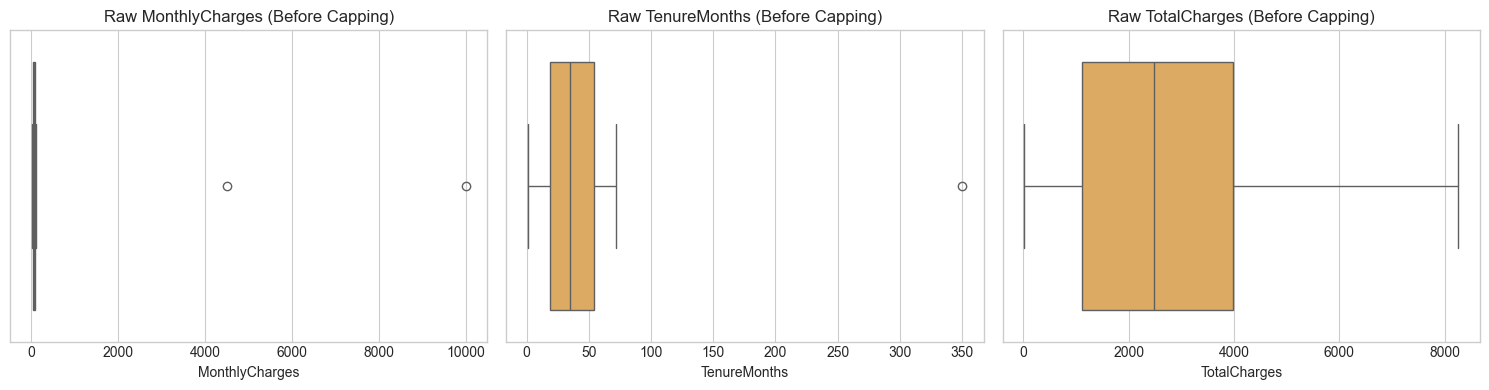

Column 'MonthlyCharges': Found 2 outliers. Capping to [5.57, 147.12] via IQR-based capping.
Column 'TenureMonths': Found 1 outliers. Capping to [-33.50, 106.50] via IQR-based capping.
Column 'TotalCharges': Found 0 outliers. Capping to [-3174.05, 8263.64] via IQR-based capping.


In [7]:
outlier_cols = ["MonthlyCharges", "TenureMonths", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df_clean[col], ax=axes[i], color="#f0ad4e")
    axes[i].set_title(f"Raw {col} (Before Capping)")

plt.tight_layout()
plt.show()

# Perform IQR-based Capping
for col in outlier_cols:
    lower_b, upper_b, mask = compute_iqr_outliers(df_clean[col])
    outlier_count = mask.sum()
    print(f"Column '{col}': Found {outlier_count} outliers. Capping to [{lower_b:.2f}, {upper_b:.2f}] via IQR-based capping.")
    df_clean[col] = np.clip(df_clean[col], lower_b, upper_b)


## 6. Feature Selection

**Rationale:**
- `CustomerID`: Unique identifier key with high cardinality and zero predictive signal. Leaving ID columns in ML models causes overfitting.
- `SystemLogCode` & `RandomNoiseScore`: Synthetic system logs and synthetic noise features that do not correlate with customer retention behavior.


In [8]:
drop_features = ["CustomerID", "SystemLogCode", "RandomNoiseScore"]
df_selected = df_clean.drop(columns=[c for c in drop_features if c in df_clean.columns])

print(f"Features dropped: {drop_features}")
print(f"Remaining columns ({len(df_selected.columns)}): {list(df_selected.columns)}")


Features dropped: ['CustomerID', 'SystemLogCode', 'RandomNoiseScore']
Remaining columns (16): ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'TenureMonths', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 7. Categorical Variable Encoding

Machine Learning algorithms require numerical inputs. We apply:
1. **Binary Encoding (0 / 1)** for binary attributes (`Gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn`).
2. **One-Hot Encoding (`pd.get_dummies`)** for nominal attributes (`Contract`, `InternetService`, `PaymentMethod`, `MultipleLines`, `OnlineSecurity`, `TechSupport`). We set `drop_first=True` to avoid the multicollinearity dummy variable trap.


In [9]:
df_encoded = df_selected.copy()

# Target Variable Encoding
df_encoded["Churn"] = df_encoded["Churn"].map({"No": 0, "Yes": 1}).astype(int)

# Binary Feature Mapping
binary_cols = ["Gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    if col == "Gender":
        df_encoded[col] = df_encoded[col].map({"Female": 0, "Male": 1}).fillna(0).astype(int)
    else:
        df_encoded[col] = df_encoded[col].map({"No": 0, "Yes": 1, 0: 0, 1: 1}).fillna(0).astype(int)

# One-Hot Encoding for Multi-class Categoricals
multi_cat_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "TechSupport", "Contract", "PaymentMethod"]
df_encoded = pd.get_dummies(df_encoded, columns=multi_cat_cols, drop_first=True, dtype=int)

print(f"Encoded DataFrame shape: {df_encoded.shape}")
df_encoded.head()


Encoded DataFrame shape: (1200, 23)


,Gender,SeniorCitizen,Partner,Dependents,TenureMonths,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,58.0,1,0,54.74,3224.65,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,1,1,1,25.0,1,0,107.38,2618.02,1,0,0,1,0,0,1,0,0,0,0,0,1,0
2,1,0,1,0,67.0,1,0,85.38,5699.19,0,0,0,1,0,0,1,0,1,1,0,0,1,0
3,0,0,0,0,44.0,1,1,75.81,882.51,0,0,0,0,1,1,0,1,0,0,1,0,0,0
4,0,0,0,0,1.0,1,0,74.61,104.23,0,0,0,1,0,0,1,0,0,0,0,0,0,0


## 8. Numerical Feature Scaling (StandardScaler)

**Why Scaling is Mandatory:**
- Continuous features like `TotalCharges` range in thousands ($0 - $7500+), while `TenureMonths` ranges from 0 to 72. Distance-based models (KNN, SVM, Logistic Regression, Neural Networks) will be dominated by features on larger scales.
- We apply `StandardScaler` (Z-score normalization) **exclusively to the 3 continuous numerical features** (`TenureMonths`, `MonthlyCharges`, `TotalCharges`) to scale them to mean $\mu = 0$ and standard deviation $\sigma = 1$:
$$z = \frac{x - \mu}{\sigma}$$
*Note: Binary and one-hot encoded features are explicitly kept in their discrete {0, 1} encoding.*


In [10]:
scaler = StandardScaler()
scale_cols = ["TenureMonths", "MonthlyCharges", "TotalCharges"]

df_scaled = df_encoded.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

print("StandardScaler applied exclusively to continuous numerical variables:")
df_scaled[scale_cols].describe().round(3).T


StandardScaler applied exclusively to continuous numerical variables:


,count,mean,std,min,25%,50%,75%,max
TenureMonths,1200.0,0.0,1.0,-1.708,-0.835,-0.058,0.864,3.412
MonthlyCharges,1200.0,0.0,1.0,-2.144,-0.594,0.061,0.757,2.783
TotalCharges,1200.0,-0.0,1.0,-1.451,-0.855,-0.113,0.699,3.029


## 9. Exploratory Data Analysis (EDA) & Insights

We now analyze patterns and relationships in the preprocessed data:
1. **Churn Target Distribution**
2. **Churn Rate by Contract Type & Internet Service**
3. **Correlation Matrix Analysis**


C:\Users\shrey\AppData\Local\Temp\ipykernel_11632\3691034170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=raw_df, x="Churn", palette=["#2b5c8f", "#d9534f"])


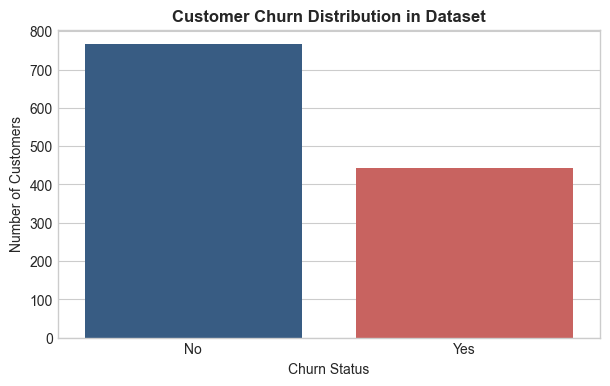

Churn Percentages:
Churn
No     63.31
Yes    36.69
Name: proportion, dtype: float64


In [11]:
# 9.1 Target Class Distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=raw_df, x="Churn", palette=["#2b5c8f", "#d9534f"])
plt.title("Customer Churn Distribution in Dataset", fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

churn_rate = (raw_df["Churn"].value_counts(normalize=True) * 100).round(2)
print("Churn Percentages:")
print(churn_rate)


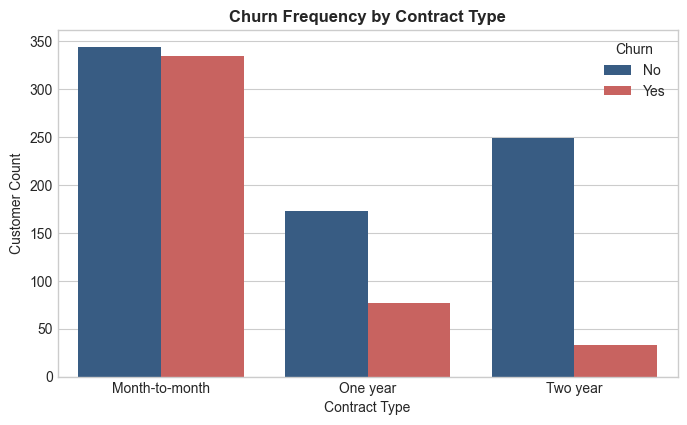

In [12]:
# 9.2 Churn Rate by Contract Type
plt.figure(figsize=(8, 4.5))
sns.countplot(data=raw_df, x="Contract", hue="Churn", palette=["#2b5c8f", "#d9534f"])
plt.title("Churn Frequency by Contract Type", fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.legend(title="Churn")
plt.show()


C:\Users\shrey\AppData\Local\Temp\ipykernel_11632\799800513.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corrs.values, y=top_corrs.index, palette="coolwarm")


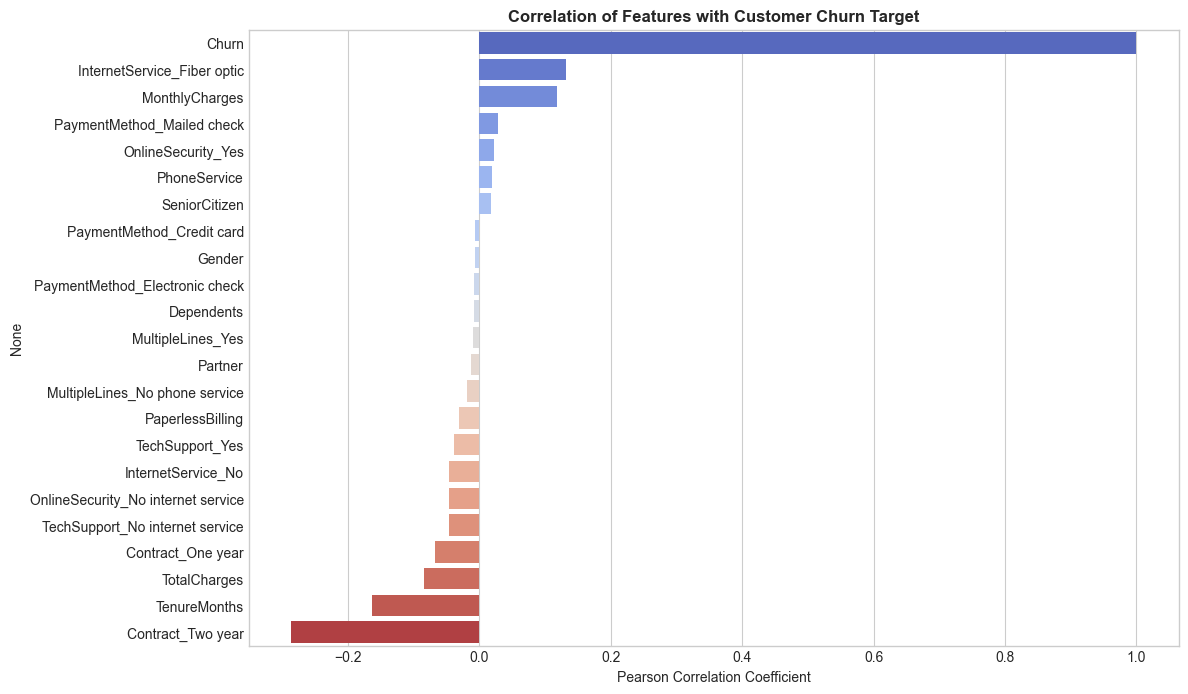

Top Positive Correlations with Churn:
Churn                          1.000000
InternetService_Fiber optic    0.131128
MonthlyCharges                 0.118479
PaymentMethod_Mailed check     0.027890
OnlineSecurity_Yes             0.021967
PhoneService                   0.018409
Name: Churn, dtype: float64

Top Negative Correlations with Churn:
OnlineSecurity_No internet service   -0.045925
TechSupport_No internet service      -0.045925
Contract_One year                    -0.067197
TotalCharges                         -0.084639
TenureMonths                         -0.164140
Contract_Two year                    -0.286973
Name: Churn, dtype: float64


In [13]:
# 9.3 Correlation Matrix of Features with Churn Target
plt.figure(figsize=(12, 8))
top_corrs = df_scaled.corr()["Churn"].sort_values(ascending=False)
sns.barplot(x=top_corrs.values, y=top_corrs.index, palette="coolwarm")
plt.title("Correlation of Features with Customer Churn Target", fontweight="bold")
plt.xlabel("Pearson Correlation Coefficient")
plt.show()

print("Top Positive Correlations with Churn:")
print(top_corrs.head(6))
print("\nTop Negative Correlations with Churn:")
print(top_corrs.tail(6))


## 10. Quantitative Before-vs-After Comparison & Data Export

We generate a summary table contrasting raw vs preprocessed data quality metrics, then export the clean CSV to `../data/processed/customer_churn_processed.csv`.


In [14]:
comparison_table = generate_before_after_comparison(raw_df, df_scaled)
print("=== PREPROCESSING BEFORE vs AFTER COMPARISON ===")
comparison_table


=== PREPROCESSING BEFORE vs AFTER COMPARISON ===


,Metric,Raw Dataset,Processed Dataset
0,Total Rows,1210.00,1200.00
1,Total Columns,19.00,23.00
2,Duplicate Rows,10.00,0.00
3,Missing Values (Total Cells),118.00,0.00
4,Categorical Columns,15.00,0.00
5,Numerical Columns,4.00,23.00
6,Memory Usage (KB),1144.57,131.25


In [15]:
# Export Clean Processed Dataset
processed_csv_path = "../data/processed/customer_churn_processed.csv"
os.makedirs(os.path.dirname(processed_csv_path), exist_ok=True)
df_scaled.to_csv(processed_csv_path, index=False)
print(f"Successfully saved clean processed dataset to '{processed_csv_path}'!")


Successfully saved clean processed dataset to '../data/processed/customer_churn_processed.csv'!


## 11. Conclusion & Key Takeaways

1. **Data Quality Improvement**:
   - Duplicate records were detected and removed.
   - Missing numerical values were imputed using robust medians; missing categorical values using modes.
   - Outliers in financial/tenure features were capped using IQR-based capping.
2. **Feature Engineering**:
   - Uninformative features (`CustomerID`, `SystemLogCode`, `RandomNoiseScore`) were removed.
   - Multi-category variables were converted into numeric dummy vectors via One-Hot Encoding.
   - Continuous features were Z-score standardized for scale invariance.
3. **Key Business Insights**:
   - Customers with **Month-to-month contracts** and **Fiber Optic internet service** exhibit significantly higher churn rates.
   - Longer tenure and two-year contract durations correlate strongly with customer retention.
